---

# `Instruções para o teste`

## ⚠️ Importante

Antes de iniciar, não esqueça de renomear esse documento substituindo o texto **SEU_NOME** no título com o nome de quem for resolver.

Deixe as respostas bem sinalizadas e comentadas e mencionando a qual questão se refere.

Fique à vontade para utilizar quantas células forem necessárias.

<br><br>

## 📖 Recursos Permitidos
✅ Documentação, sites, fóruns  
❌ Inteligências Artificiais (ChatGPT, Claude, etc.)

<br><br>

## 📤 Instruções para Entrega

**Ao finalizar o teste** volte a este passo e execute a célula abaixo.

**Envie o arquivo gerado e o arquivo do seu notebook para o e-mail:** `mateus.camacho@tdwbi.com.br`

- Arquivo gerado: `historico_exec.txt` <br>
- Seu notebook: `teste_spark_SEU_NOME.ipynb`


In [22]:
with open('/content/historico_exec.txt', 'w') as f:
    for i, cmd in enumerate(In):
        if cmd.strip():
            f.write(f"\n\nIn[{i}]:\n{cmd}\n\n")

# Baixar arquivo
from google.colab import files
files.download('/content/historico_exec.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# `Questões e Contexto`

## 📁 Contexto

No diretório raiz desse documento, existem os três arquivos que serão necessários para a conclusão dessa atividade. Em caso de dúvidas, a pasta de se encontra no desktop dessa máquina na pasta 'pyspark_test'.

Os dados são fictícios e compreendem uma simulação de um cenário de uma loja de departamentos, para isso temos os arquivos com as seguintes informações:
- **users.csv** → Dados dos clientes/usuários da loja
- **sales.csv** → Dados das vendas
- **products.json** → Dados de cadastro dos produtos

<br><br>

## 📝 Questões

A atividade consiste nas questões a seguir:

**1.** Declare um novo dataframe que mostre o nome do produto e o valor final da compra.

**2.** Declare um novo dataframe com o valor total gasto por cliente.

**3.** Declare um novo dataframe com os cinco melhores clientes contendo o nome, e-mail e o valor gasto em todo o período.

**4.** Declare um novo dataframe com os cinco produtos mais vendidos nos últimos seis meses (considerando período de dados disponível nos arquivos) contendo o nome do produto e a quantidade de produtos vendidos nesse período.

**5.** Calcular a média de faturamento por cliente e o desvio padrão.

**6.** Classificar os clientes em três categorias: silver, gold, platinum
- **platinum:** clientes que gastaram mais que a média de faturamento por cliente;
- **gold:** clientes que gastaram do menor desvio padrão até a média de faturamento por cliente;
- **silver:** clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente;

**7.** Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente.

---

# `Configuração do ambiente`

**Execute as células abaixo antes de iniciar o teste.**

Os arquivos serão criados automaticamente e estarão disponíveis no ícone de pasta do menu lateral (conforme imagem abaixo) ou na pasta **content**.

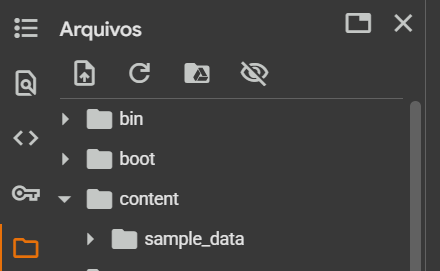


In [2]:
### IMPORTANDO ARQUIVOS QUE SERÃO USADOS NO TESTE ###

!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json -O products.json
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv -O sales.csv
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/users.csv -O users.csv

path_products = "/content/products.json"
path_sales = "/content/sales.csv"
path_users = "/content/users.csv"

--2026-03-05 14:40:00--  https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3186 (3.1K) [text/plain]
Saving to: ‘products.json’

products.json       100%[===================>]   3.11K  --.-KB/s    in 0s      

2026-03-05 14:40:00 (35.3 MB/s) - ‘products.json’ saved [3186/3186]

--2026-03-05 14:40:00--  https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24411 (24K) [text/plain]


In [13]:
### IMPORTANDO BIBLIOTECAS NECESSÁRIAS ###

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [5]:
### INSTANCIANDO SPARK ###

spark = SparkSession.builder.appName('test-spark-diego-maximo-albuquerque').getOrCreate()

---

# Seu teste começa aqui 🍀 Boa sorte!

In [7]:
# Questão 1

df_vendas = spark.read.csv("sales.csv", header = True, inferSchema= True)
df_produtos = spark.read.json("products.json")

#Df de produtos precisa de limpeza, pois possui "$"
df_produtos = df_produtos.withColumn(
    "price",
    regexp_replace(col("price"), "\\$", "").cast("double")
)

#Com o DF limpo, farei um join de vendas x produtos
df_resultado = df_vendas.join(df_produtos, on="product_id").withColumn("valor_final", round(col("qtde") * col("price"), 2)).select("product", "valor_final")

#print da resposta
df_resultado.show()

+------------------+-----------+
|           product|valor_final|
+------------------+-----------+
|     Blusa Cropped|      214.5|
|Camiseta Estampada|     218.38|
|     Óculos de Sol|     244.54|
|        Bolsa Tote|     105.96|
|     Camisa Social|     161.52|
|Conjunto de Pijama|      85.49|
|     Camiseta Polo|     224.04|
|        Macaquinho|     191.32|
|     Chapéu Fedora|     301.77|
|    Blusa de Renda|       98.9|
|     Camisa Xadrez|      102.7|
|         Sapatênis|     251.76|
|        Sapatilhas|     123.33|
|       Camisa Polo|      259.5|
| Casaco de Inverno|     235.76|
|Suéter de Cashmere|      82.64|
|Calça Cintura Alta|      218.6|
|     Camiseta Polo|     336.06|
|     Jaqueta Jeans|     116.02|
|  Vestido Camisola|       95.6|
+------------------+-----------+
only showing top 20 rows


In [8]:
# Questão 2

#criado o df de usuários
df_usuarios = spark.read.csv("users.csv", header=True, inferSchema=True)

#join entre os 3 df vendas x produto x usuarios
df_gasto_por_cliente = df_vendas.join(df_produtos, on="product_id") \
.join(df_usuarios, on="client_id") \
.withColumn("valor_final", col("qtde") * col("price")) \
.groupBy("client_id", "name") \
.agg(round(sum("valor_final"), 2).alias("total_gasto")) \
.orderBy("total_gasto", ascending= False)

#print da resposta
df_gasto_por_cliente.show()


+---------+--------------------+-----------+
|client_id|                name|total_gasto|
+---------+--------------------+-----------+
|      131|   Randa Friedenbach|    2240.51|
|      245|     Giuditta Blease|    1902.85|
|       24|        Cher Higford|    1843.35|
|      200|       Keen Juggings|    1795.86|
|       31|       Alfie Pattlel|     1755.6|
|       53|    Pieter Gawthorpe|    1751.67|
|      222| Margarethe Prigmore|    1713.44|
|       19|     Brandie Winning|    1690.69|
|      168|       Newton Nother|    1616.26|
|      210|      Germaine Pagen|    1600.66|
|      263|         Alec Pigdon|    1554.22|
|      220|     Samaria Bottjer|    1549.11|
|      134|       Dulcy Birkett|    1518.37|
|      189|      Arvy Scutching|    1517.77|
|      284|         Ethyl Yoxen|    1501.65|
|      165|     Humfrid Traylen|    1489.71|
|       96|           Lexis Ert|    1464.33|
|       98|    Sunshine Sewards|    1443.01|
|      240|Wilmette Lotterin...|    1411.71|
|      123

In [9]:
# Questão 3

#criado df de top 5 clientes
df_top5clientes = df_vendas.join(df_produtos, on="product_id") \
.join(df_usuarios, on="client_id") \
.withColumn("valor_final", col("qtde") * col("price")) \
.groupBy("client_id", "name", "email") \
.agg(round(sum("valor_final"), 2).alias("total_gasto")) \
.orderBy("total_gasto", ascending=False) \
.limit(5)

#print da resposta
df_top5clientes.show(truncate=False)

+---------+-----------------+-------------------------+-----------+
|client_id|name             |email                    |total_gasto|
+---------+-----------------+-------------------------+-----------+
|131      |Randa Friedenbach|rfriedenbach3m@paypal.com|2240.51    |
|245      |Giuditta Blease  |gblease6s@friendfeed.com |1902.85    |
|24       |Cher Higford     |chigfordn@issuu.com      |1843.35    |
|200      |Keen Juggings    |kjuggings5j@phoca.cz     |1795.86    |
|31       |Alfie Pattlel    |apattlelu@discuz.net     |1755.6     |
+---------+-----------------+-------------------------+-----------+



In [14]:
# Questão 4

#precisa converter coluna date para o tipo Date
df_date_vendas = df_vendas.withColumn("date", to_date(col("date"), "dd/MM/yyyy"))

#coleta a data maxima do df
data_maxima = df_date_vendas.agg(max("date")).collect()[0][0]

#Filtrar os ultimos 6 meses a partir do data_maxima
df_top5produtos = df_date_vendas.filter(col("date") >= add_months(lit(data_maxima), -6)) \
.join(df_produtos, on="product_id") \
.groupBy("product_id", "product") \
.agg(sum("qtde").alias("quantidade_vendida")) \
.orderBy("quantidade_vendida", ascending = False) \
.limit(5)

df_top5produtos.show(truncate=False)

+----------+--------------------+------------------+
|product_id|product             |quantidade_vendida|
+----------+--------------------+------------------+
|39        |Macaquinho          |39                |
|7         |Blusa de Manga Longa|34                |
|12        |Casaco de Inverno   |29                |
|50        |Blusa de Malha      |29                |
|44        |Mochila de Lona     |27                |
+----------+--------------------+------------------+



In [15]:
# Questão 5

df_media_desvio_padrao = df_vendas.join(df_produtos, on="product_id") \
.join(df_usuarios, on="client_id") \
.withColumn("valor_final", col("qtde") * col("price")) \
.groupBy("client_id", "name") \
.agg(round(avg("valor_final"), 2).alias("media_gasto"),
     round(stddev("valor_final"), 2).alias("desvio_padrão")) \
.orderBy("media_gasto", ascending=False)

df_media_desvio_padrao.show(truncate=False)


+---------+-----------------+-----------+-------------+
|client_id|name             |media_gasto|desvio_padrão|
+---------+-----------------+-----------+-------------+
|153      |Lorrie Harvie    |368.43     |NULL         |
|21       |Morgana Kenen    |348.06     |NULL         |
|85       |Kylie Bolton     |344.46     |39.67        |
|8        |Aime Cheyney     |337.74     |NULL         |
|107      |Deonne Twine     |336.24     |NULL         |
|225      |Don Friman       |336.15     |0.13         |
|49       |Hilliard Wadforth|334.77     |47.6         |
|68       |Jory Vickors     |330.81     |NULL         |
|55       |Dewitt Christofle|330.18     |NULL         |
|252      |Allison Bardill  |322.65     |50.44        |
|300      |Corbett St. Paul |319.13     |45.71        |
|248      |Priscella Gaywood|308.1      |NULL         |
|166      |Eba Larderot     |306.57     |66.57        |
|189      |Arvy Scutching   |303.55     |107.22       |
|84       |Samuele Whiff    |301.03     |93.03  

In [18]:
# Questão 6

#cria o df de total gasto p cliente
df_total_por_cliente = df_vendas.join(df_produtos, on="product_id") \
.join(df_usuarios, on="client_id") \
.withColumn("valor_final", col("qtde") * col("price")) \
.groupby("client_id", "name") \
.agg(round(sum("valor_final"), 2).alias("total_gasto"))

metricas = df_total_por_cliente.agg(avg("total_gasto").alias("media"),
                                    stddev("total_gasto").alias("desvio")).collect()[0]

media = metricas["media"]
desvio_padrao = metricas["desvio"]

df_classificados = df_total_por_cliente.withColumn("categoria",
                                                   when(col("total_gasto") > media, "platinum")
                                                   .when(col("total_gasto") >= (media - desvio_padrao), "gold")
                                                   .otherwise("silver")
                                                   )
df_classificados.show(truncate=False)

+---------+-------------------+-----------+---------+
|client_id|name               |total_gasto|categoria|
+---------+-------------------+-----------+---------+
|180      |Eva Coppock.       |659.3      |gold     |
|249      |Towny Stamper      |516.16     |gold     |
|102      |Christin Chellenham|1296.35    |platinum |
|270      |Tammi Blancowe     |484.62     |gold     |
|134      |Dulcy Birkett      |1518.37    |platinum |
|88       |Lorenza Klemencic  |413.55     |gold     |
|152      |Ericka Mottinelli  |728.48     |platinum |
|220      |Samaria Bottjer    |1549.11    |platinum |
|1        |Mitch Kilpatrick   |244.39     |silver   |
|155      |Cammy Solway       |974.77     |platinum |
|201      |Sharla Colnett     |506.87     |gold     |
|271      |Tedman Gerssam     |1043.94    |platinum |
|239      |Nathanil Wannan    |334.49     |gold     |
|34       |Trenton Phillipp   |851.9      |platinum |
|256      |Tremaine Peacher   |1372.82    |platinum |
|235      |Cammy Ebbage     

In [21]:
# Questão 7
from pyspark.sql.window import Window

df_consumo = df_vendas.join(df_produtos, on="product_id") \
.join(df_classificados.select("client_id", "categoria"), on="client_id") \
.groupBy("categoria", "product_id", "product") \
.agg(sum("qtde").alias("quantidade_vendida")) \
.cache()

window_categoria = Window.partitionBy("categoria").orderBy(col("quantidade_vendida").desc())

df_top3_por_categoria = df_consumo.withColumn("rank", dense_rank().over(window_categoria)) \
                                              .filter(col("rank") <= 3) \
                                              .drop("rank", "product_id") \
                                              .orderBy("categoria", col("quantidade_vendida").desc())

df_top3_por_categoria.write.mode("overwrite").parquet("top3_produtos_por_categoria.parquet")

df_top3_por_categoria.show(truncate=False)

+---------+---------------------+------------------+
|categoria|product              |quantidade_vendida|
+---------+---------------------+------------------+
|gold     |Casaco de Inverno    |26                |
|gold     |Cinto de Couro       |26                |
|gold     |Camisa Xadrez        |23                |
|gold     |Calça Legging        |21                |
|platinum |Blusa de Manga Longa |57                |
|platinum |Mochila de Lona      |52                |
|platinum |Calça Cintura Alta   |45                |
|silver   |Macaquinho           |7                 |
|silver   |Sapatos de Salto Alto|6                 |
|silver   |Calça Flare          |5                 |
|silver   |Conjunto de Pijama   |5                 |
|silver   |Vestido Midi         |5                 |
|silver   |Calça Jeans          |5                 |
+---------+---------------------+------------------+

